# 04 - Exploratory Data Analysis (EDA)

This notebook performs a detailed exploratory data analysis on the training split only.

The test set is not loaded to prevent information leakage and to keep it completely unseen until the final model evaluation.

The analysis includes:

- Dataset structure and feature types
- Missing values
- Numerical features
- Categorical features
- Relationships with the target
- Date and time patterns
- Geographic patterns

## Load the Training Split

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

EDA_DIR = PROJECT_ROOT / "artifacts" / "eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
train_data = pd.read_csv(PROJECT_ROOT / "data" / "train.csv")

print("Training Shape:", train_data.shape)
train_data.head()

Training Shape: (67529, 22)


,order_purchase_timestamp,order_approved_at,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,total_price,total_freight,item_count,total_payment,...,seller_count,seller_state_count,seller_states,seller_zip_code_prefix,customer_lat,customer_lng,seller_lat,seller_lng,distance_km,is_late
0,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-04,14600,sao joaquim da barra,SP,134.97,8.49,3.0,NaN,...,1.0,1.0,PR,81810.0,-20.585751,-47.863693,-25.507014,-49.275963,565.959812,1
1,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-27,4106,sao paulo,SP,29.90,15.56,1.0,45.46,...,1.0,1.0,PR,85801.0,-23.581451,-46.635029,-24.959184,-53.462644,708.754247,0
2,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-11-07,98280,panambi,RS,21.90,17.19,1.0,39.09,...,1.0,1.0,SP,15802.0,-28.293541,-53.502238,-21.143389,-48.995314,915.912412,0
3,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-11-29,90040,porto alegre,RS,36.49,17.24,1.0,53.73,...,1.0,1.0,SP,18015.0,-30.041161,-51.213661,-23.502755,-47.430451,818.146504,0
4,2016-10-03 22:06:03,2016-10-04 10:28:07,2016-11-23,13185,hortolandia,SP,119.90,13.56,1.0,133.46,...,1.0,1.0,SP,14940.0,-22.892792,-47.173849,-21.757321,-48.829744,212.014865,0


In [ ]:
train_data["order_purchase_timestamp"] = pd.to_datetime(
    train_data["order_purchase_timestamp"])

print("First order:", train_data["order_purchase_timestamp"].min())
print("Last order:", train_data["order_purchase_timestamp"].max())

First order: 2016-09-15 12:16:38
Last order: 2018-04-15 20:12:35


## 1. Dataset Structure and Feature Types

Overall structure of the training dataset: 
- shape
- data types

In [4]:
print("Number of rows:", train_data.shape[0])
print("Number of columns:", train_data.shape[1])

print("\nDataset information:")
train_data.info(memory_usage="deep")


Number of rows: 67529
Number of columns: 22

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 67529 entries, 0 to 67528
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_purchase_timestamp       67529 non-null  datetime64[us]
 1   order_approved_at              67515 non-null  str           
 2   order_estimated_delivery_date  67529 non-null  str           
 3   customer_zip_code_prefix       67529 non-null  int64         
 4   customer_city                  67529 non-null  str           
 5   customer_state                 67529 non-null  str           
 6   total_price                    67529 non-null  float64       
 7   total_freight                  67529 non-null  float64       
 8   item_count                     67529 non-null  float64       
 9   total_payment                  67528 non-null  float64       
 10  payment_installments       

In [5]:
print(train_data.columns.to_list())

['order_purchase_timestamp', 'order_approved_at', 'order_estimated_delivery_date', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'total_price', 'total_freight', 'item_count', 'total_payment', 'payment_installments', 'payment_count', 'seller_count', 'seller_state_count', 'seller_states', 'seller_zip_code_prefix', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng', 'distance_km', 'is_late']


### Feature Type Classification

The features are classified based on their meaning rather than only their pandas data type.

- **Date/Time:** `order_purchase_timestamp`, `order_approved_at`, `order_estimated_delivery_date`

- **Numerical:** `total_price`, `total_freight`, `item_count`, `total_payment`, `payment_installments`, `payment_count`, `seller_count`, `seller_state_count`, `distance_km`

- **Categorical:** `customer_city`, `customer_state`, `seller_states`

- **Geographic identifiers:** `customer_zip_code_prefix`, `seller_zip_code_prefix`

- **Coordinates:** `customer_lat`, `customer_lng`, `seller_lat`, `seller_lng`

- **Target:** `is_late`

Date columns are initially stored as strings and are converted to datetime before temporal analysis.

ZIP code prefixes are geographic identifiers rather than continuous numerical variables.

## 2. Missing Values Analysis

In [6]:
missing_count = train_data.isnull().sum()

missing_percent = (train_data.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({"missing_count": missing_count,
"missing_percent": missing_percent
})


In [7]:
missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_percent
distance_km,1116,1.65
customer_lng,181,0.27
customer_lat,181,0.27
seller_lng,165,0.24
seller_lat,165,0.24
order_approved_at,14,0.02
payment_count,1,0.00
total_payment,1,0.00
payment_installments,1,0.00


**Investigating Missing Values in Approval Dates**

In [8]:
missing_approved = train_data[
    train_data["order_approved_at"].isnull()
]

print("Missing approval dates:", len(missing_approved))

missing_approved[
    [
        "order_purchase_timestamp",
        "customer_state",
        "total_payment",
        "payment_installments",
        "is_late"
    ]
]

Missing approval dates: 14


,order_purchase_timestamp,customer_state,total_payment,payment_installments,is_late
472,2017-01-19 12:48:08,SP,54.51,1.0,0
490,2017-01-19 22:26:59,MG,60.42,1.0,0
2113,2017-02-17 13:05:55,RJ,95.76,1.0,0
2120,2017-02-17 15:53:27,RS,157.19,1.0,0
2125,2017-02-17 17:21:55,MG,154.23,1.0,0
2143,2017-02-18 11:04:19,SP,39.95,1.0,0
2150,2017-02-18 12:45:31,RS,396.86,1.0,0
2152,2017-02-18 13:29:47,SP,65.52,1.0,0
2161,2017-02-18 14:40:00,SP,349.01,1.0,0
2170,2017-02-18 15:52:27,MG,77.06,1.0,0


In [9]:
missing_approved["is_late"].value_counts()

is_late
0    14
Name: count, dtype: int64

#### Missing Approval Date Insight

- Only 11 training orders have a missing `order_approved_at`, and all are on-time orders.

- Because the number of affected observations is very small, no strong pattern should be inferred from these cases. The missing values are kept for later preprocessing.

## 3. Numerical Feature Analysis

In [10]:
numerical_cols = [
    "total_price",
    "total_freight",
    "item_count",
    "total_payment",
    "payment_installments",
    "payment_count"
]

In [11]:
train_data[numerical_cols].describe()

,total_price,total_freight,item_count,total_payment,payment_installments,payment_count
count,67529.000000,67529.000000,67529.000000,67528.000000,67528.000000,67528.000000
mean,135.888797,22.245936,1.142072,158.173637,2.974559,1.047625
std,205.194019,20.002594,0.541640,214.285757,2.755168,0.397223
min,2.290000,0.000000,1.000000,10.070000,1.000000,1.000000
25%,45.900000,14.100000,1.000000,61.630000,1.000000,1.000000
50%,85.000000,16.790000,1.000000,104.190000,2.000000,1.000000
75%,149.900000,23.700000,1.000000,175.500000,4.000000,1.000000
max,13440.000000,1002.290000,21.000000,13664.080000,24.000000,26.000000


In [12]:
skewness = (
    train_data[numerical_cols]
    .skew()
    .sort_values(ascending=False)
)

skewness

payment_count           22.419509
total_price             10.718895
total_payment           10.149318
total_freight            8.581743
item_count               8.107162
payment_installments     1.592665
dtype: float64

In [13]:
range_check = pd.DataFrame({
"min": train_data[numerical_cols].min(),
"max": train_data[numerical_cols].max(),
"zeros": (train_data[numerical_cols] == 0).sum(),
"negative": (train_data[numerical_cols] < 0).sum()
})

range_check

,min,max,zeros,negative
total_price,2.29,13440.00,0,0
total_freight,0.00,1002.29,10,0
item_count,1.00,21.00,0,0
total_payment,10.07,13664.08,0,0
payment_installments,1.00,24.00,0,0
payment_count,1.00,26.00,0,0


In [14]:
train_data[
    train_data["payment_installments"] == 0
][[
    "total_price",
    "total_freight",
    "total_payment",
    "payment_installments",
    "payment_count",
    "is_late"
]]

,total_price,total_freight,total_payment,payment_installments,payment_count,is_late


In [15]:
zero_freight = (train_data["total_freight"] == 0).sum()
zero_freight_pct = zero_freight / len(train_data) * 100

print("Zero freight orders:", zero_freight)
print("Percentage:", round(zero_freight_pct, 2), "%")

Zero freight orders: 10
Percentage: 0.01 %


### Numerical Distributions

All numerical features show positive skewness, indicating right-skewed distributions. Several variables also contain extreme values.

Extreme observations are treated as potential outliers rather than automatically considered errors

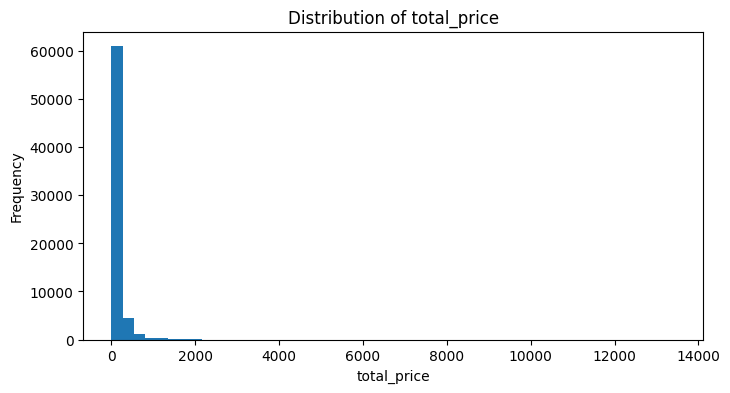

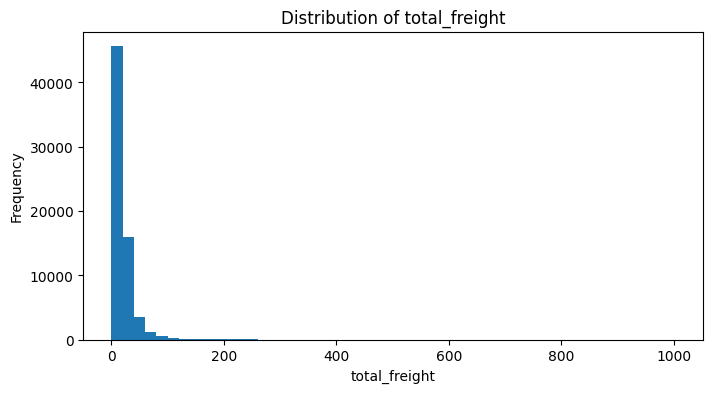

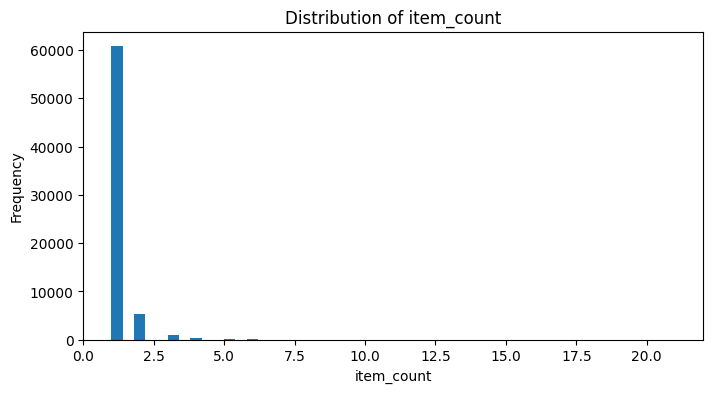

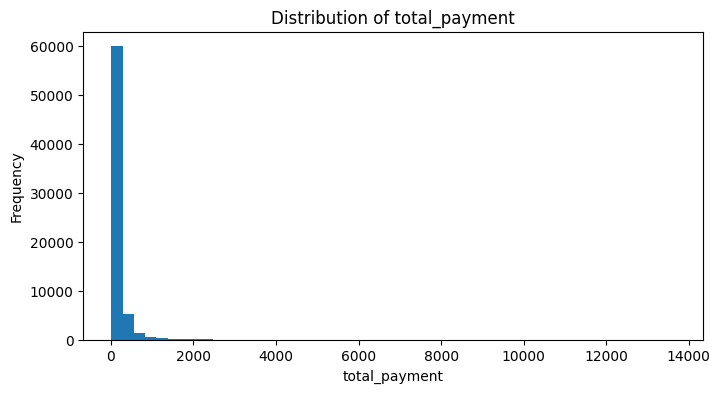

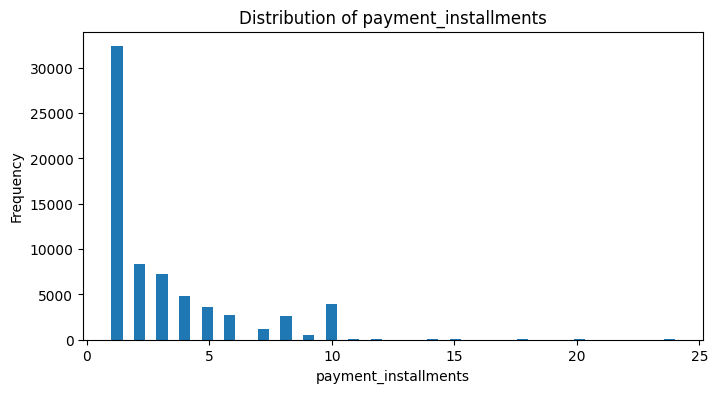

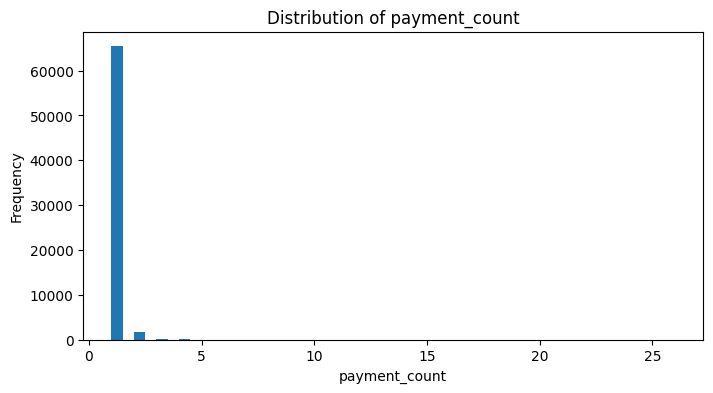

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(train_data[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.savefig(EDA_DIR / "distribution_of_numerical_columns.png",
    bbox_inches="tight")
    plt.show()

### Numerical Distribution Findings

1. The numerical features are generally right-skewed, with most observations concentrated at relatively low values and a small number of very large observations.

2. `total_price`, `total_freight`, and `total_payment` show particularly long right tails. Similarly, most orders contain one item and one payment record, while a small number of orders contain substantially larger counts.

3. No negative numerical values were found, and item_count and payment_count have sensible minimum values of 1.

4. There are 234 orders (0.35%) with zero freight cost. These observations may represent free-shipping orders and are therefore not treated as errors now.

5. Two orders have payment_installments = 0 despite having positive payment values and one payment record. These observations are unusual and should be treated as potential data anomalies rather than automatically removed.

6. Extreme numerical values are considered potential outliers, but they are not assumed to be invalid without investigation.

### Outliers

In [17]:
outlier_summary = []

for col in numerical_cols:
    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = train_data[
        (train_data[col] < lower_bound) |
        (train_data[col] > upper_bound)
    ]

    outlier_summary.append({
        "feature": col,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers),
        "outlier_percent": len(outliers) / len(train_data) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary.round(2)

,feature,lower_bound,upper_bound,outlier_count,outlier_percent
0,total_price,-110.10,305.9,5362,7.94
1,total_freight,-0.30,38.1,6630,9.82
2,item_count,1.00,1.0,6758,10.01
3,total_payment,-109.18,346.3,5309,7.86
4,payment_installments,-3.50,8.5,4678,6.93
5,payment_count,1.00,1.0,2129,3.15


### Outlier Analysis

- The IQR method shows potential outliers in the numerical features. 

- The observations are not automatically considered data errors. The strong right-skewness of the monetary variables naturally produces many observations above the upper IQR threshold.

- For `item_count` and `payment_count`, both the first and third quartiles are equal to 1, resulting in an IQR of zero. Therefore, the IQR rule classifies every value above 1 as an outlier. In this context, such values can represent valid orders containing multiple items or multiple payment records.

- Similarly, high installment counts may be unusual but can still represent valid payment behavior.

Potential outliers will be retained unless there is additional information that they represent invalid data.

## 4. Categorical Feature Analysis

In [18]:
categorical_cols = ["customer_city", "customer_state"]

for col in categorical_cols:
    print(f"\n---{col}---")
    print("Unique categories:", train_data[col].nunique())
    print("\nTop 10 categories:")
    print(train_data[col].value_counts().head(10))


---customer_city---
Unique categories: 3747

Top 10 categories:
customer_city
sao paulo                9920
rio de janeiro           4777
belo horizonte           1869
brasilia                 1395
curitiba                 1020
porto alegre              975
campinas                  967
salvador                  823
guarulhos                 724
sao bernardo do campo     622
Name: count, dtype: int64

---customer_state---
Unique categories: 27

Top 10 categories:
customer_state
SP    27204
RJ     8965
MG     8129
RS     3912
PR     3461
SC     2576
BA     2307
ES     1445
GO     1409
DF     1404
Name: count, dtype: int64


In [19]:
cardinality = pd.DataFrame({
    "feature": categorical_cols,
    "unique_values": [
        train_data[col].nunique()
        for col in categorical_cols
    ]
})
cardinality

,feature,unique_values
0,customer_city,3747
1,customer_state,27


In [20]:
for col in categorical_cols:
    spaces = (train_data[col] != train_data[col].str.strip()).sum()
    print(col, "leading/trailing spaces:", spaces)

customer_city leading/trailing spaces: 0
customer_state leading/trailing spaces: 0


In [21]:
for col in categorical_cols:
    counts = train_data[col].value_counts()

    rare = counts[counts < 10]

    print(f"\n--- {col} ---")
    print("Number of rare categories (<10 observations):", len(rare))
    print("Percentage of categories that are rare:",
          round(len(rare) / len(counts) * 100, 2), "%")


--- customer_city ---
Number of rare categories (<10 observations): 2992
Percentage of categories that are rare: 79.85 %

--- customer_state ---
Number of rare categories (<10 observations): 0
Percentage of categories that are rare: 0.0 %


In [22]:
for col in categorical_cols:
    original_unique = train_data[col].nunique()

    cleaned = (train_data[col].str.strip().str.lower())
    
    cleaned_unique = cleaned.nunique()

    print(f"\n--- {col} ---")
    print("Original unique:", original_unique)
    print("Unique after basic cleaning:", cleaned_unique)
    print("Possible duplicated/messy categories:",
          original_unique - cleaned_unique)


--- customer_city ---
Original unique: 3747
Unique after basic cleaning: 3747
Possible duplicated/messy categories: 0

--- customer_state ---
Original unique: 27
Unique after basic cleaning: 27
Possible duplicated/messy categories: 0


### Categorical Insight

- `customer_city` has high cardinality with 3,692 unique values.
- 80.5% of city categories appear fewer than 10 times.
- `customer_state` has only 27 categories.
- No duplicated categories were found after basic cleaning.
- No leading or trailing spaces were detected.

## 5. Relations with the Target

This section explores how the available features are related to the target variable is_late.

In [23]:
numerical_cols = [
    "total_price",
    "total_freight",
    "item_count",
    "total_payment",
    "payment_installments",
    "payment_count"
]

train_data.groupby("is_late")[numerical_cols].mean().round(2)

,total_price,total_freight,item_count,total_payment,payment_installments,payment_count
is_late,,,,,,
0,134.51,21.95,1.14,156.50,2.96,1.05
1,149.79,25.20,1.11,175.03,3.12,1.04


In [24]:
correlation = train_data[
    numerical_cols + ["is_late"]
].corr()

correlation["is_late"].sort_values(ascending=False)

is_late                 1.000000
total_freight           0.046597
total_payment           0.024776
total_price             0.021336
payment_installments    0.017183
payment_count          -0.005890
item_count             -0.016130
Name: is_late, dtype: float64

### Correlation with the Target

- All numerical features have very weak linear correlations with is_late.

- total_freight has the highest positive correlation, but it is still very small (0.023). This suggests that no numerical feature alone has a strong linear relationship with late delivery.

In [25]:
state_late_rate = (train_data.groupby(
    "customer_state")['is_late'].
    agg(["count", "mean"]).
    rename(columns={
        "count": "orders",
        "mean": "late_rate"
    })
)

state_late_rate["late_rate"] = (state_late_rate["late_rate"]*100).round(2)


state_late_rate.sort_values("late_rate", ascending=False)

,orders,late_rate
customer_state,,
AL,298,27.85
MA,548,21.53
CE,948,18.25
RR,29,17.24
SE,246,17.07
PI,348,16.67
RJ,8965,16.59
BA,2307,15.00
PA,718,13.37


### State vs Late Delivery

Late delivery rates vary across customer states.

Some states such as AL and MA have higher late-delivery rates, while states such as SP and PR have lower rates.

States with very small order counts should be interpreted carefully.

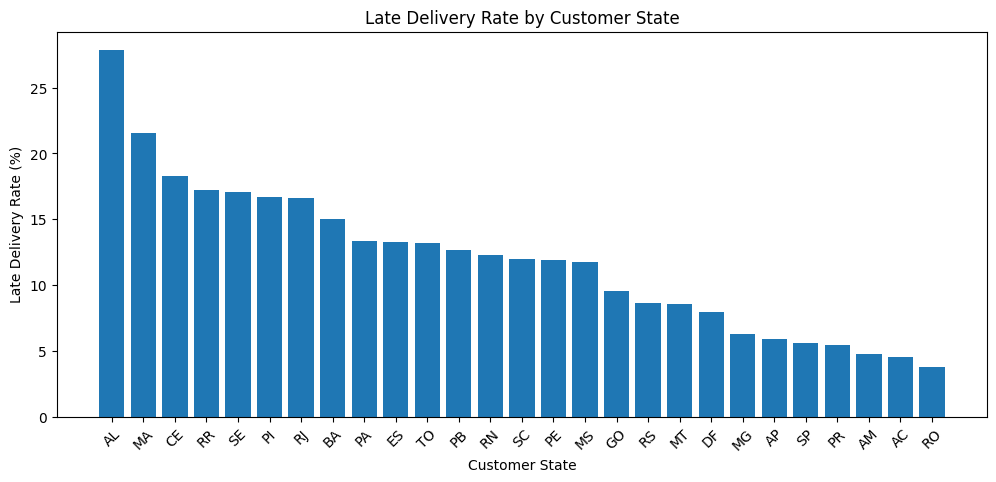

In [ ]:
state_plot = state_late_rate.sort_values("late_rate", ascending=False)

plt.figure(figsize=(12, 5))

plt.bar(state_plot.index, state_plot["late_rate"])

plt.title("Late Delivery Rate by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)
plt.savefig(EDA_DIR / "late_delivery_rate_by_customer_state.png",bbox_inches="tight")
plt.show()

## 6. Date and Time Analysis

Date features are explored to identify temporal patterns in orders and late deliveries.

> Actual delivery timestamps are not used in this EDA because they directly reveal the delivery outcome and would cause target leakage. The analysis focuses on date information available before delivery.

In [27]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_estimated_delivery_date"
]

for col in date_cols:
    train_data[col] = pd.to_datetime(train_data[col])

train_data[date_cols].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [28]:
train_data["purchase_year"] = train_data["order_purchase_timestamp"].dt.year
train_data["purchase_month"] = train_data["order_purchase_timestamp"].dt.month
train_data["purchase_weekday"] = train_data["order_purchase_timestamp"].dt.day_name()
train_data["purchase_hour"] = train_data["order_purchase_timestamp"].dt.hour

In [29]:
print("First order:", train_data["order_purchase_timestamp"].min())
print("Last order:", train_data["order_purchase_timestamp"].max())


monthly_orders = (train_data.set_index("order_purchase_timestamp").resample("ME").size())

First order: 2016-09-15 12:16:38
Last order: 2018-04-15 20:12:35


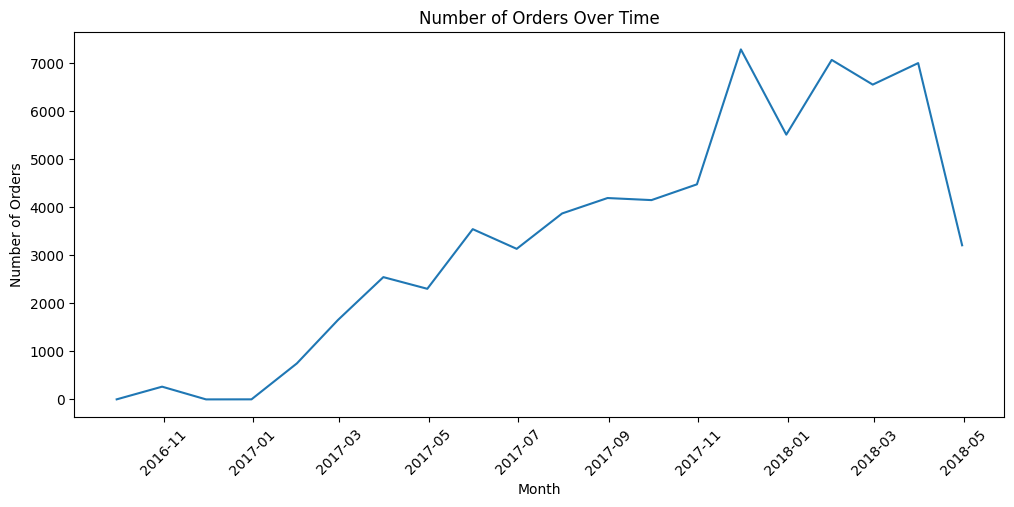

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_orders.index, monthly_orders.values)
plt.title("Number of Orders Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.savefig(EDA_DIR / "number_of_orders_over_time.png",bbox_inches="tight")
plt.show()



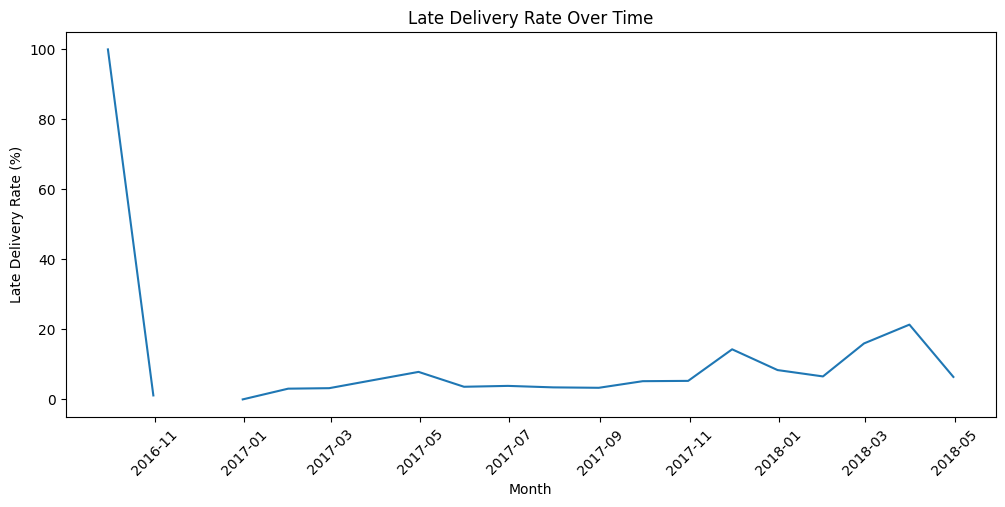

In [ ]:
monthly_late_rate = (train_data.set_index("order_purchase_timestamp").resample("ME")["is_late"].mean() * 100)

plt.figure(figsize=(12, 5))
plt.plot(monthly_late_rate.index, monthly_late_rate.values)
plt.title("Late Delivery Rate Over Time")
plt.xlabel("Month")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)

plt.savefig(EDA_DIR / "late_delivery_rate_over_time.png",bbox_inches="tight")
plt.show()

#### Orders and Late Deliveries Over Time

- The number of orders generally increased over time.

- Late delivery rates also vary across months, with some  peaks. This suggests that time and seasonality may be related to delivery delays.

In [32]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_analysis = (train_data.groupby("purchase_weekday")['is_late'].agg(['count', 'mean']).reindex(weekday_order))

weekday_analysis['mean'] = (weekday_analysis['mean']*100).round(2)

weekday_analysis.columns = ['order', 'late_rate']
weekday_analysis

,order,late_rate
purchase_weekday,,
Monday,10734,10.01
Tuesday,10729,9.26
Wednesday,10339,8.61
Thursday,10005,8.29
Friday,9884,9.47
Saturday,7593,8.97
Sunday,8245,8.38


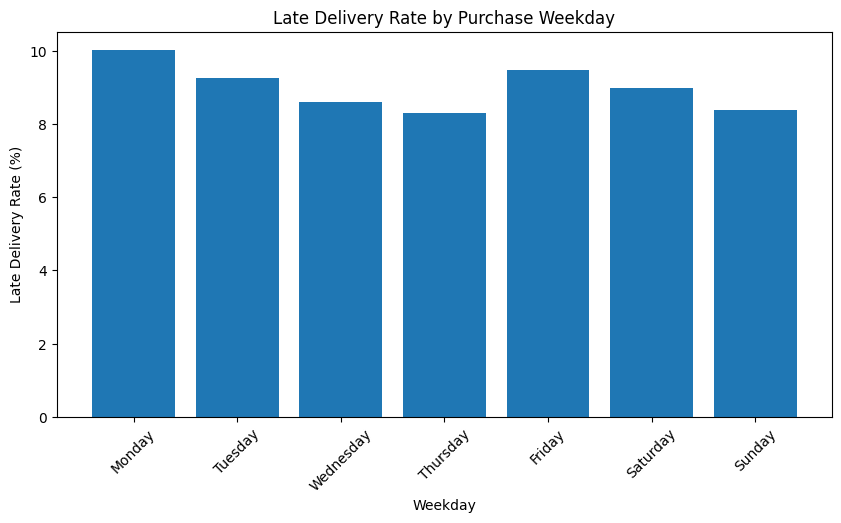

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(weekday_analysis.index, weekday_analysis["late_rate"])

plt.title("Late Delivery Rate by Purchase Weekday")
plt.xlabel("Weekday")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)

plt.savefig(EDA_DIR / "late_delivery_rate_by_purchase_weekday.png",bbox_inches="tight")

plt.show()

#### Weekday Effect

- Late delivery rates vary slightly across purchase weekdays.

- Overall, the differences between weekdays are relatively small.

#### Estimated Delivery Window

In [34]:
train_data["estimated_delivery_days"] = (
    train_data["order_estimated_delivery_date"]
    - train_data["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

train_data["estimated_delivery_days"].describe()

count    67529.000000
mean        24.595253
std          8.018400
min          7.005127
25%         19.543333
50%         23.621331
75%         28.564965
max        155.135463
Name: estimated_delivery_days, dtype: float64

In [35]:
train_data.groupby("is_late")[
    "estimated_delivery_days"
].agg(["count", "mean", "median", "min", "max"]).round(2)

,count,mean,median,min,max
is_late,,,,,
0,61433,24.67,23.81,7.05,155.14
1,6096,23.88,23.33,7.01,69.34


#### Estimated Delivery Window Insight

The average estimated delivery window is about 23.8 days.

Late orders have a slightly shorter estimated delivery window (22.0 days) compared with on-time orders (23.9 days).

This descriptive difference suggests that the estimated delivery window may contain useful predictive information. However, EDA alone does not establish that this feature will improve model performance.

In [36]:
train_data["delivery_window_group"] = pd.cut(
    train_data["estimated_delivery_days"],
    bins=[0, 10, 20, 30, 40, float("inf")],
    labels=["0-10", "11-20", "21-30", "31-40", "40+"]
)

window_late_rate = (
    train_data
    .groupby("delivery_window_group", observed=False)["is_late"]
    .mean()
    .mul(100)
    .round(2)
)

window_late_rate

delivery_window_group
0-10     12.12
11-20     8.36
21-30    10.13
31-40     7.65
40+       3.41
Name: is_late, dtype: float64

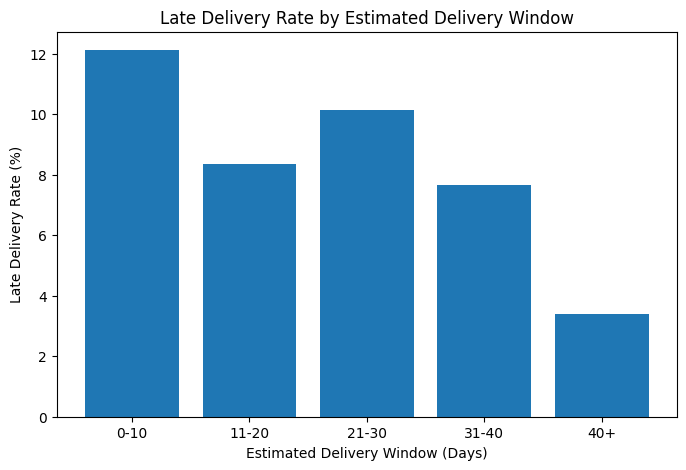

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    window_late_rate.index.astype(str),
    window_late_rate.values
)

plt.title("Late Delivery Rate by Estimated Delivery Window")
plt.xlabel("Estimated Delivery Window (Days)")
plt.ylabel("Late Delivery Rate (%)")

plt.savefig(EDA_DIR / "late_delivery_rate_by_estimated_delivery_window.png",bbox_inches="tight")

plt.show()

#### Delivery Window Groups Insight
Orders with very short estimated delivery windows (0–10 days) have the highest late-delivery rate.

Longer delivery windows generally show lower late-delivery rates, although the pattern is not perfectly linear.

In [38]:
monthly_analysis = (
    train_data
    .groupby("purchase_month")["is_late"]
    .agg(["count", "mean"])
)

monthly_analysis["mean"] = (
    monthly_analysis["mean"] * 100
).round(2)

monthly_analysis.columns = ["orders", "late_rate"]

monthly_analysis

,orders,late_rate
purchase_month,,
1,7819,6.23
2,8208,13.41
3,9549,17.15
4,5512,7.02
5,3545,3.61
6,3135,3.86
7,3872,3.43
8,4193,3.32
9,4151,5.23


### Monthly Seasonality

- Late-delivery rates vary across months.

- March, November, and February show higher late-delivery rates, while June has the lowest rate.

- This suggests a possible seasonal effect on delivery delays.

### Holiday Effect


In [39]:
import holidays

# Brazilian public holidays for the years in the training data
br_holidays = holidays.Brazil(
    years=train_data["order_purchase_timestamp"].dt.year.unique()
)

# Extract purchase date
train_data["purchase_date"] = train_data[
    "order_purchase_timestamp"
].dt.date

# Mark whether the purchase date was a public holiday
train_data["is_holiday"] = train_data["purchase_date"].isin(br_holidays)

train_data["is_holiday"].value_counts()

is_holiday
False    66458
True      1071
Name: count, dtype: int64

**Holiday vs Late Delivery**

In [40]:
holiday_late = (
    train_data
    .groupby("is_holiday")["is_late"]
    .agg(["count", "mean"])
)

holiday_late["late_rate"] = (
    holiday_late["mean"] * 100
).round(2)

holiday_late

,count,mean,late_rate
is_holiday,,,
False,66458,0.090614,9.06
True,1071,0.069094,6.91


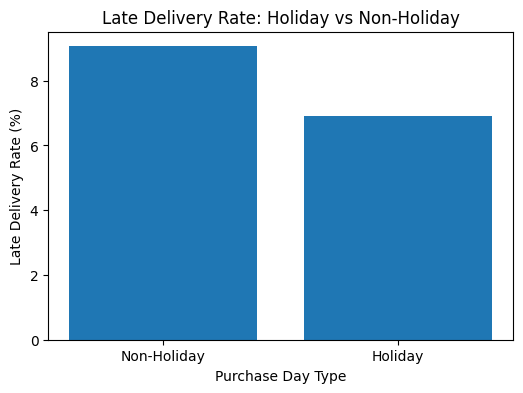

In [ ]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["Non-Holiday", "Holiday"],
    holiday_late["late_rate"]
)

plt.title("Late Delivery Rate: Holiday vs Non-Holiday")
plt.xlabel("Purchase Day Type")
plt.ylabel("Late Delivery Rate (%)")

plt.savefig(EDA_DIR / "late_delivery_rate_holiday_vs_Non.png",bbox_inches="tight")

plt.show()

#### Holiday Insight

Orders purchased on public holidays had a lower late delivery rate (6.45%) than orders purchased on non-holidays (8.14%). However, holiday orders are much less frequent, so this difference should be interpreted carefully.

## 7. Geography

### **7.1 Customer ZIP Analysis**

In [42]:
print("Unique ZIP prefixes:",
      train_data["customer_zip_code_prefix"].nunique())

print("\nTop 10 ZIP prefixes:")
print(
    train_data["customer_zip_code_prefix"]
    .value_counts()
    .head(10)
)

Unique ZIP prefixes: 13748

Top 10 ZIP prefixes:
customer_zip_code_prefix
22790    113
22793     89
24220     82
24230     81
22775     80
29101     73
35162     69
22631     64
37200     63
35500     62
Name: count, dtype: int64


In [43]:
zip_analysis = (
    train_data
    .groupby("customer_zip_code_prefix")["is_late"]
    .agg(["count", "mean"])
)

zip_analysis["late_rate"] = (
    zip_analysis["mean"] * 100
).round(2)

zip_analysis = zip_analysis[
    zip_analysis["count"] >= 30
]

zip_analysis.sort_values(
    "late_rate",
    ascending=False
).head(15)

,count,mean,late_rate
customer_zip_code_prefix,,,
22793,89,0.359551,35.96
45810,31,0.322581,32.26
22743,32,0.312500,31.25
88058,34,0.294118,29.41
13060,45,0.288889,28.89
22723,32,0.281250,28.12
28300,33,0.272727,27.27
21330,35,0.257143,25.71
13050,42,0.238095,23.81


### Customer ZIP Prefix Insight

- Customer ZIP prefix has high cardinality.
- Late-delivery rates vary across ZIP areas.
- The comparison is limited to ZIP prefixes with at least 30 orders to reduce unstable rates from very small groups.
- Although geographic variation is visible, the high cardinality of ZIP prefixes should be considered before using this variable directly in the model.

_____

### **7.2 Seller State Analysis**

Seller location is analyzed to explore whether late-delivery rates vary across seller states.

To avoid ambiguity, this analysis is limited to orders associated with a single seller state.

In [44]:
single_state_orders = train_data[
    train_data["seller_state_count"] == 1
].copy()

seller_state_analysis = (
    single_state_orders
    .groupby("seller_states")["is_late"]
    .agg(["count", "mean"])
)

seller_state_analysis["late_rate"] = (
    seller_state_analysis["mean"] * 100
).round(2)

seller_state_analysis.sort_values(
    "late_rate",
    ascending=False
)

,count,mean,late_rate
seller_states,,,
AM,3,0.666667,66.67
MA,63,0.380952,38.10
CE,55,0.127273,12.73
PA,8,0.125000,12.50
RN,45,0.111111,11.11
PB,18,0.111111,11.11
RJ,2668,0.098951,9.90
SP,47735,0.098230,9.82
PR,5307,0.077633,7.76


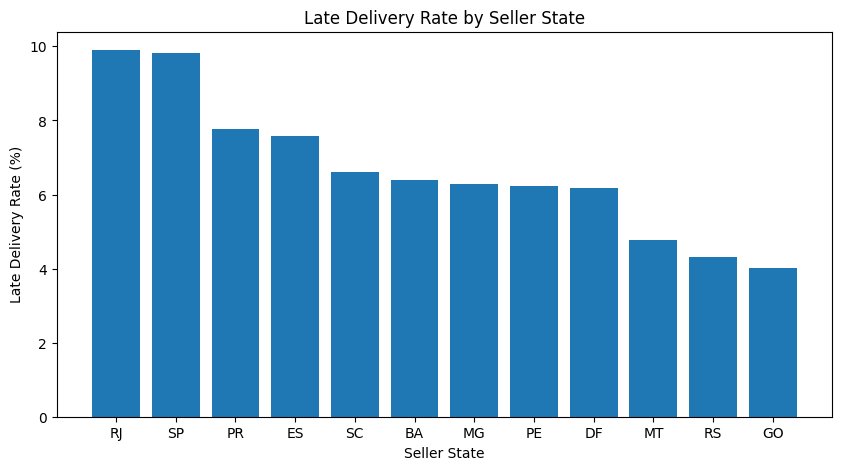

In [45]:
seller_state_plot = seller_state_analysis[
    seller_state_analysis["count"] >= 100
].sort_values("late_rate", ascending=False)

plt.figure(figsize=(10, 5))

plt.bar(
    seller_state_plot.index,
    seller_state_plot["late_rate"]
)

plt.title("Late Delivery Rate by Seller State")
plt.xlabel("Seller State")
plt.ylabel("Late Delivery Rate (%)")
plt.savefig("artifacts/eda/late_delivery_rate_by_seller_state.png",bbox_inches="tight")

plt.show()

### Seller State Insight

- Late-delivery rates vary across seller states.
- Among seller states with at least 100 orders, some states show noticeably higher late-delivery rates than others.
- This descriptive variation suggests that seller location may contain useful predictive information, although EDA alone does not establish a causal relationship.

### **7.3 Customer-Seller Distance Analysis**

In [46]:
# Use single-seller orders with available distance
distance_valid = train_data[
    (train_data["seller_count"] == 1) &
    (train_data["distance_km"].notna())
].copy()

print("Single-seller orders with valid distance:", len(distance_valid))

distance_valid["distance_km"].describe()

Single-seller orders with valid distance: 66413


count    66413.000000
mean       615.313042
std        595.922489
min          0.000000
25%        219.272290
50%        448.651338
75%        811.581496
max       5338.619521
Name: distance_km, dtype: float64

In [47]:
distance_valid.groupby("is_late")["distance_km"].agg(["count", "mean", "median"]).round(2)

,count,mean,median
is_late,,,
0,60371,598.95,437.53
1,6042,778.83,552.68


In [48]:
distance_valid["distance_group"] = pd.cut(
    distance_valid["distance_km"],
    bins=[0, 100, 300, 500, 1000, 2000, float("inf")],
    labels=["0-100", "101-300", "301-500", "501-1000", "1001-2000", "2000+"],
    include_lowest=True
)

distance_late_rate = (
    distance_valid
    .groupby("distance_group", observed=False)["is_late"]
    .agg(["count", "mean"])
)

distance_late_rate["late_rate"] = (distance_late_rate["mean"] * 100).round(2)

distance_late_rate

,count,mean,late_rate
distance_group,,,
0-100,11503,0.048596,4.86
101-300,9052,0.070371,7.04
301-500,16553,0.092853,9.29
501-1000,18371,0.100648,10.06
1001-2000,6934,0.122296,12.23
2000+,4000,0.153000,15.30


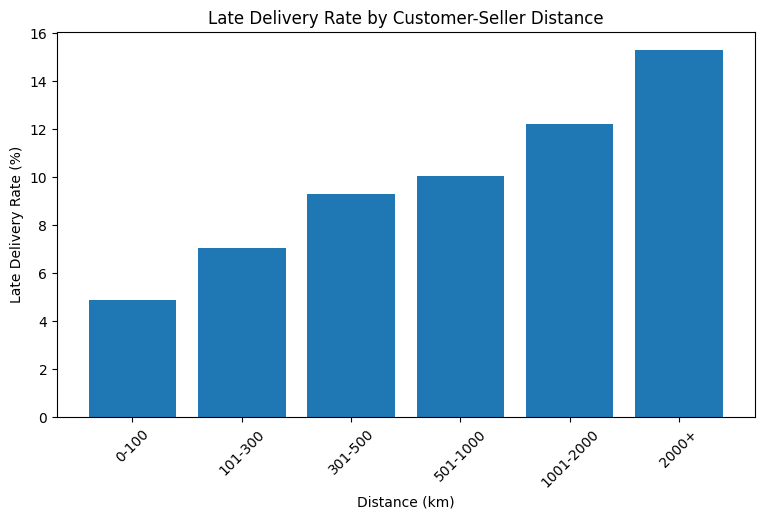

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(distance_late_rate.index.astype(str), distance_late_rate["late_rate"])

plt.title("Late Delivery Rate by Customer-Seller Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)

plt.savefig(EDA_DIR / "late_delivery_rate_by_customer_seller_distance.png",bbox_inches="tight")

plt.show()

### Distance Insight

- Among single-seller orders with available geographic information, late-delivery rates generally increase across larger customer-seller distance groups.
- This descriptive pattern suggests that distance may contain useful predictive information for late-delivery classification.

## Save EDA Insights

In [51]:
eda_findings = """
EDA Findings Summary

- The target variable is imbalanced, with late deliveries representing a relatively small proportion of training orders.
- Delivery patterns vary across customer and seller geographic locations.
- Customer-seller distance shows a descriptive association with late-delivery rates.
- The estimated delivery window shows differences between on-time and late orders and may contain useful predictive information.
- Several numerical variables are right-skewed and contain extreme values, which are not automatically treated as invalid observations.
- Purchase timing variables, including month, weekday, hour, and holidays, were explored for possible temporal patterns.
- Some geographic variables have high cardinality and therefore require careful consideration before encoding.
- Based on the EDA, selected order, payment, seller, geographic, and time-related variables will be considered during feature engineering.
"""

In [ ]:
with open(EDA_DIR / "eda_findings.txt","w",encoding="utf-8") as f:
    f.write(eda_findings)

print("EDA findings summary saved.")

EDA findings summary saved.
